# AQI Forecasting Using Machine Learning & Deep Learning
## 1. Imports & Data Loading


In [ ]:
# First, I am importing the fundamental libraries needed for data manipulation and visualization.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# I am setting pandas options to display all columns so nothing is hidden when I inspect the dataframe.
# I also disable chained assignment warnings to keep my output clean.
pd.set_option('display.max_columns', None)
pd.options.mode.chained_assignment = None

# Since I am using Google Colab, I need to mount my Google Drive to access the dataset.
from google.colab import drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Now, I am loading the AQI dataset from my drive into a pandas DataFrame.
df = pd.read_csv('/content/drive/MyDrive/AQI_dataset.csv')

## 2. Initial Exploratory Data Analysis (EDA)
Inspecting data shape, statistics, and missing values.


In [ ]:
# Let's take a quick look at the first 5 rows to understand what the data looks like.

# I always check df.head() after a major operation to visually confirm my changes applied correctly.
df.head()

# I am checking the data types of each column and looking for any immediate missing values.
df.info()

# Let's generate some basic summary statistics (mean, min, max, etc.) for the numerical columns.
# Viewing df.describe() helps me spot impossible values (e.g. negative AQI) in the numerical columns quickly.
df.describe()

# I want to see the total number of rows in my dataset to calculate percentages later.
# Snagging the total row count so I can convert my missing-value sums into clean percentages.
total = df.shape[0]

# Here, I am calculating the percentage of missing (null) values for every single column
# and sorting them in descending order to see which features are missing the most data.
((df.isnull().sum()/(total))*100).sort_values(ascending = False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


,0
Xylene,61.322001
PM10,37.723071
NH3,34.973418
Toluene,27.229014
Benzene,19.041008
AQI,15.851139
AQI_Bucket,15.851139
PM2.5,15.570079
NOx,14.171549
O3,13.619586


## 3. Data Cleaning
Dropping sparse columns, removing NaNs in target variables, filtering cities with sparse data, and isolating unrealistic pollutant readings.


In [ ]:
# I decided to drop several columns because they either have too many missing values
# or are not directly useful for predicting the overall AQI in my approach.
# I am dropping columns like 'Xylene' and 'Toluene' because they have massive gaps that interpolate() can't safely fix.
df = df.drop(columns = ['Xylene','PM10','NH3','Toluene','Benzene','AQI_Bucket','NOx'])

df.head()

# Printing df.shape lets me track exactly how many rows and columns I lose during each cleaning step.
df.shape

# The 'AQI' column is my target variable. If the target is missing, the row is useless for training.
# Therefore, I am dropping any rows where the AQI itself is NaN.
df = df.dropna(subset = 'AQI')

df.shape

((df.isnull().sum()/(total))*100).sort_values(ascending = False)

# For some core pollutants, extremely small values (below 1) are likely sensor errors or just noise.
# I am converting any value less than 1 to NaN so it can be handled properly later.
# These are the core pollutants I actually care about. If these are corrupted, the prediction is meaningless.
pollutants = ["PM2.5", "NO", "NO2", "SO2", "O3"]


df[pollutants] = df[pollutants].applymap(lambda x: np.nan if x < 1 else x)


# To prevent extreme outliers from confusing my models, I am clipping the maximum AQI value to 500
# (which is generally the maximum reading for severe pollution anyway).

df["AQI"] = df["AQI"].clip(upper=500)

# I only want to train on cities that have a reliable, long history of data.
# Here, I am filtering the dataset to only keep cities that have at least 1000 days of readings.

# Counting the occurrences of each city to see which ones have enough historical data to be useful.
city_counts = df['City'].value_counts()
# If a city has less than 1000 days of data, it will actively hurt the training process, so I isolate the 'valid' ones.
valid_cities = city_counts[city_counts >= 1000].index.tolist()
# I filter the main dataframe to only keep rows belonging to my 'valid_cities' list.
df = df[df['City'].isin(valid_cities)]
# Outputting exactly how many cities survived my strict filtering.
print(f'Retained {df.City.nunique()} cities with sufficient data.')

# Finally, for the remaining core features, I am simply dropping any rows that still contain NaNs.
# I do this to ensure absolute data integrity, avoiding any leakage from improper imputation.
features = ['PM2.5', 'NO', 'NO2', 'SO2', 'O3', 'CO']

df = df.dropna(subset=features)
print(f'Cleaned Shape: {df.shape}')

Retained 12 cities with sufficient data.
Cleaned Shape: (16876, 9)


/tmp/ipykernel_552/3798890523.py:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[pollutants] = df[pollutants].applymap(lambda x: np.nan if x < 1 else x)


## 4. Distribution Analysis & Skew Validation
Checking for skewness and generating visualizations. (Note: Actual Yeo-Johnson transforms and Outlier Clipping are handled securely inside CV folds to prevent data leakage).


PM2.5 : 2.795
NO2 : 2.406
SO2 : 4.081
NO : 3.362
CO : 7.541
O3 : 1.371
AQI : 1.171
PM2.5 : 0.208
NO2 : -0.051
SO2 : 4.081
NO : 3.362
CO : 7.541
O3 : 0.339
AQI : 0.276


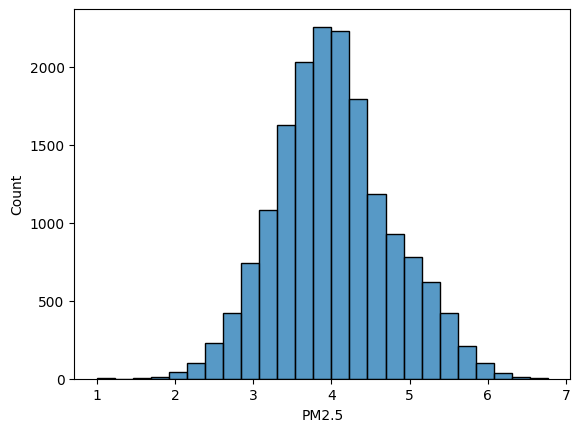

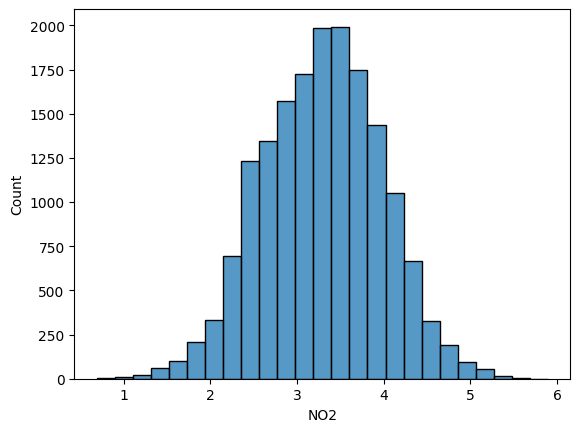

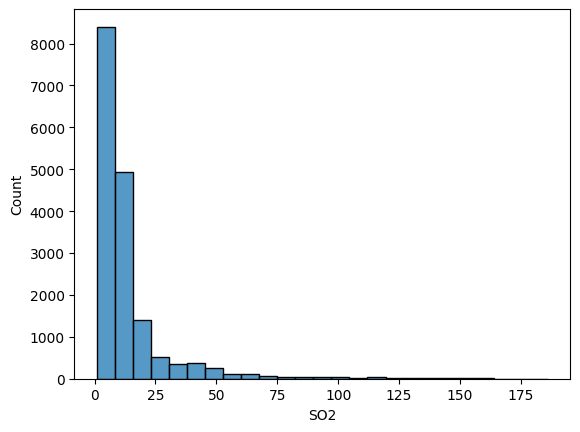

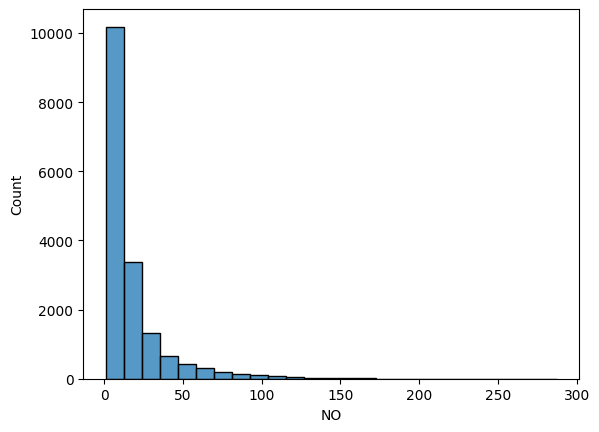

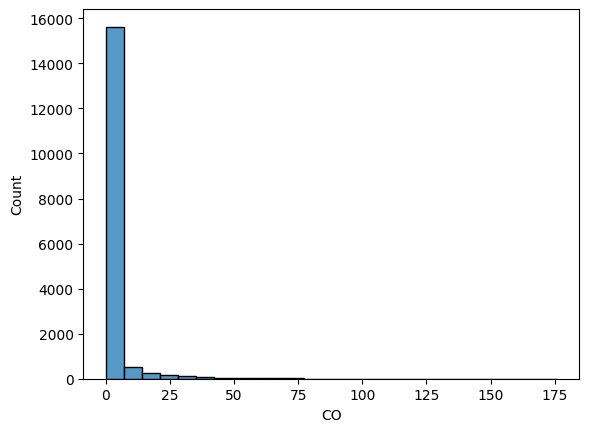

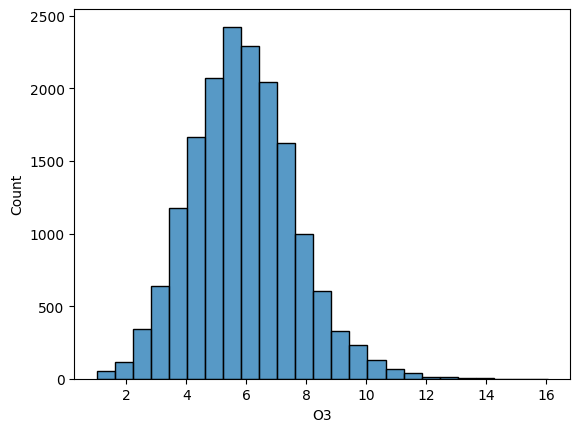

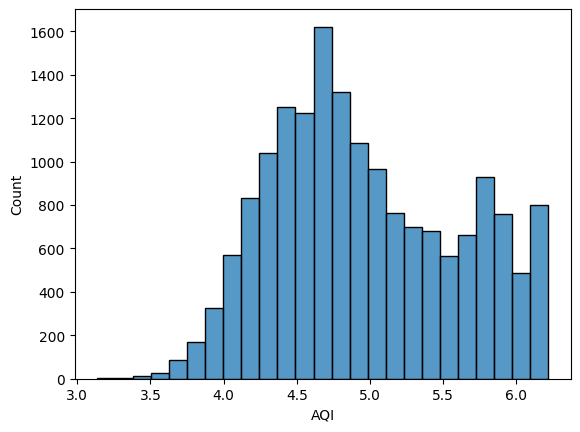

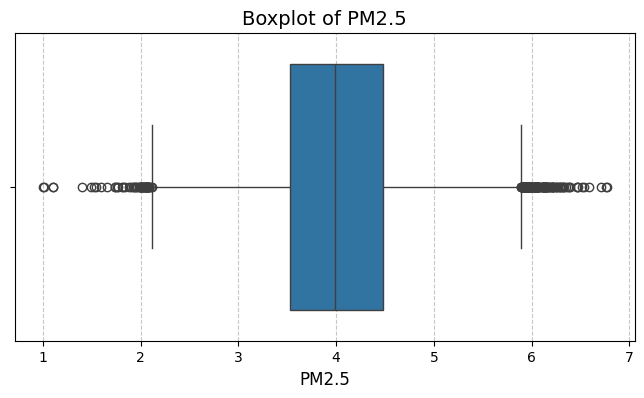

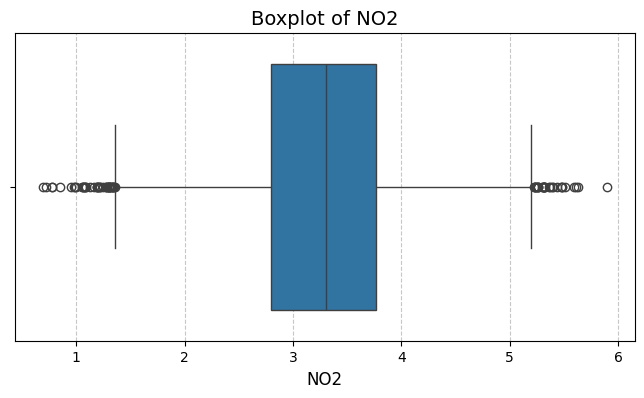

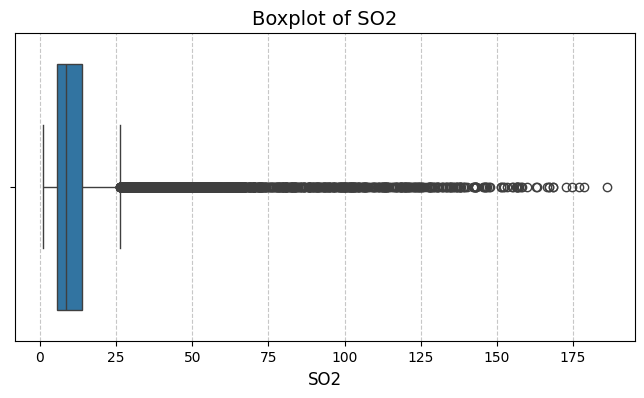

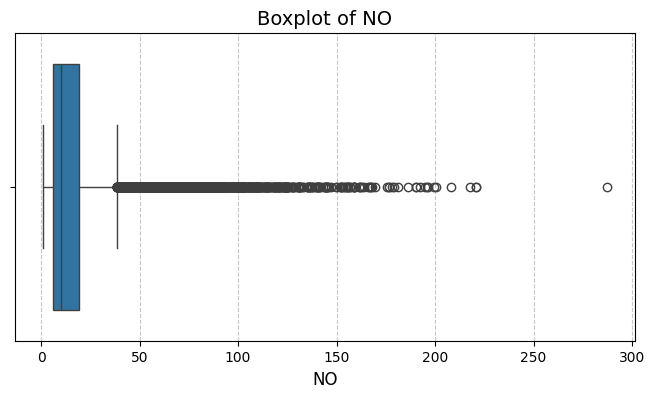

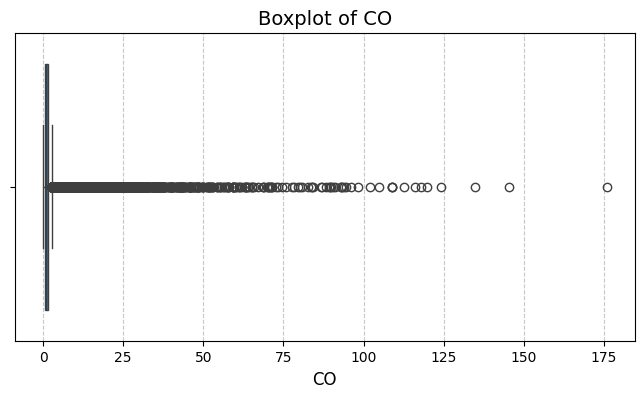

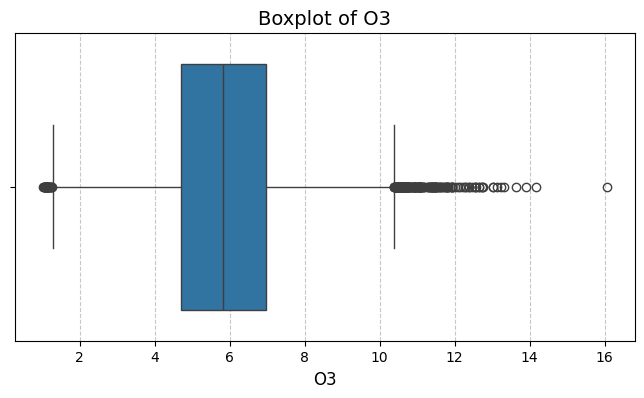

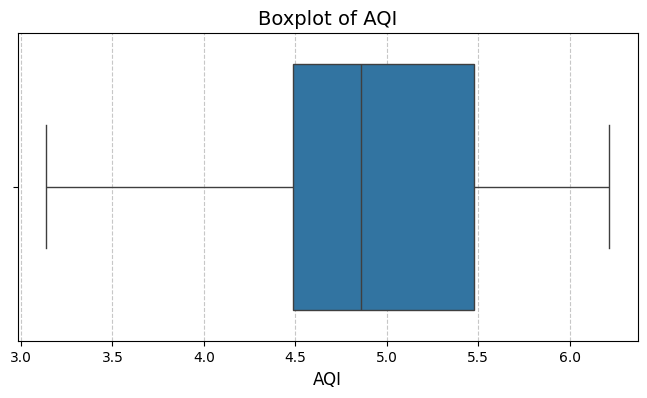

In [ ]:

df.describe()

# Many machine learning models assume data is normally distributed (like a bell curve).
# I am checking the 'skewness' of my target and main features.
# A value far from 0 means the data is heavily skewed (mostly concentrated on one side).
cols = ["PM2.5", "NO2", "SO2", "NO", "CO", "O3","AQI"]
for col in cols:
    print(f'{col} : {(df[col].skew()):.3f}')


# To help normalize the skewed features, I will use some mathematical transformations.
from sklearn.preprocessing import PowerTransformer, QuantileTransformer


# For Ozone (O3), I found that a simple square root transformation reduces the skew nicely.
df['O3'] = np.sqrt(df['O3'])

cols = ["PM2.5", "NO2" ,"AQI"]
for col in cols:
# For highly skewed features like PM2.5, NO2, and the AQI itself,
# I am applying a Logarithmic transformation (np.log1p securely handles 0 values).

    df[col] = np.log1p(df[col])

cols = ["PM2.5", "NO2", "SO2", "NO", "CO", "O3","AQI"]
for col in cols:
    print(f'{col} : {(df[col].skew()):.3f}')

cols = ["PM2.5", "NO2", "SO2", "NO", "CO", "O3","AQI"]
for col in cols:
# Now, I want to visually inspect the distributions using histograms.
# You can see the data looks much closer to a normal 'bell curve' shape now.
    sns.histplot(data = df, x = col , bins = 25)

    plt.show()


for col in cols:
    plt.figure(figsize=(8, 4))
# I am also generating boxplots to visually identify any remaining extreme outliers in each feature.
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}', fontsize=14)

    plt.xlabel(col, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()


## 5. Correlation Analysis
Analyzing the linear relationship between pollutants and the AQI.


Correlation with AQI
PM2.5 : 0.828
NO2 : 0.485
SO2 : 0.413
NO : 0.495
CO : 0.386
O3 : 0.276
AQI : 1.000


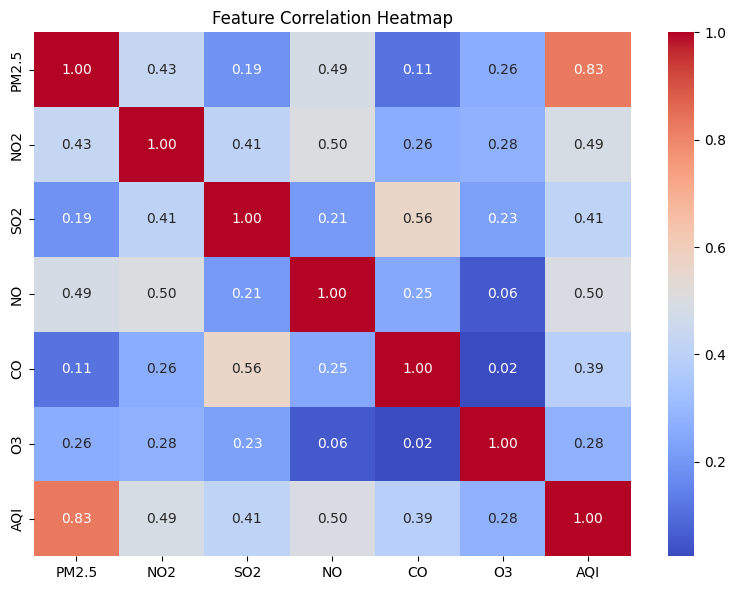

In [ ]:
cols = ["PM2.5", "NO2", "SO2", "NO", "CO", "O3","AQI"]
# To understand which pollutants drive the AQI the most, I am looking at their linear correlation.
# A value close to 1 means strong positive correlation, while a value close to 0 means no correlation.
print("Correlation with AQI")
for col in cols:
    val = df[[col,'AQI']].corr().values.tolist()[0][1]

    print(f'{col} : {val:.3f}')

plt.figure(figsize=(8, 6))
# A heatmap is the best way to visualize all these correlations simultaneously.
# This helps me spot if two features are doing the exact same thing (multicollinearity).
corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 6. Time-Series Feature Engineering
1. Formatting Date Index and Temporal Resampling (Interpolation) to fix gap shifts.
2. Cyclical Encoding (Sine/Cosine for Day/Month).
3. Generating Pollutant Lags (1, 3, 7 days) and Rolling Windows (3, 7, 14 days).


In [ ]:
# First, I ensure the Date column is a proper datetime object so pandas understands it's a date.
# Pandas needs to explicitly know this is a Date, or else it treats it just like a random string of text.
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')


# When tracking history (e.g., "what was the AQI yesterday?"), missing days ruin the math.
# I am forcing pandas to resample the data daily ('D') for each city.
# This inserts explicit blank rows for any calendar days that were entirely missing from the CSV.
df = df.set_index('Date').groupby('City').resample('D').asfreq()

if 'City' in df.columns:
    df = df.drop(columns=['City'])
df = df.reset_index()

# Now I make sure the data is perfectly chronological for each city.
# Sorting is critical! If the dates jump back and forth, my rolling averages and lags will pull future data into the past.
df = df.sort_values(by=['City', 'Date'])

# For tiny gaps (up to 3 missing days in a row), I am interpolating the values
# based on the surrounding days (connecting the dots).
# If a gap is larger than 3 days, I deliberately leave it as NaN to prevent wild guessing.
# Interpolation throws a lot of noisy warnings, so I am temporarily muting them to keep the output clean.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    df = df.set_index('Date').groupby('City').apply(lambda group: group.interpolate(method='time', limit=3))

    if 'City' in df.columns:
        df = df.drop(columns=['City'])
    df = df.reset_index()


# I am extracting specific time elements (day, month, weekend status)
# because pollution changes heavily based on rush hours, weekends, and winter/summer seasons.
df['Day_of_week'] = df['Date'].dt.dayofweek

df['Month'] = df['Date'].dt.month

# Extracting the 'Quarter' (1, 2, 3, 4) can help the model recognize broad seasonal shifts (Winter vs Monsoon).
df['Quarter'] = df['Date'].dt.quarter
# I create a binary (1/0) 'Is_weekend' flag because traffic pollution drops significantly on Saturdays and Sundays.
df['Is_weekend'] = df['Day_of_week'].isin([5,6]).astype(int)
df['Day_of_year'] = df['Date'].dt.dayofyear


# Machine learning models don't naturally know that December (12) is next to January (1).
# I am using Sine and Cosine waves to encode days and months cyclically so the model understands the continuous loop of a calendar year.
df['Dow_sin'] = np.sin(2 * np.pi * df['Day_of_week']/7)
df['Dow_cos'] = np.cos(2 * np.pi * df['Day_of_week']/7)


df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12)


# I can drop the linear versions now that I have the cyclical ones encoded.
df = df.drop(columns = ['Month','Day_of_week'])

df.head()


# A massive predictor of tomorrow's pollution is today's pollution.
# I am generating historical "lag" columns.
# For example, 'PM2.5_lag1' represents the PM2.5 value from exactly 1 day ago for that specific city.
lag_cols = ["AQI", "PM2.5", "NO2", "CO"]

for col in lag_cols:
    current_lags = [1, 7, 30] if col == "AQI" else [1, 3, 7]

    for lag in current_lags:
        df[f'{col}_lag{lag}'] = df.groupby('City')[col].shift(lag)


# Sometimes a single day's lag isn't enough; we want the moving average of the last few days.
# I am calculating 3-day (and 7, 14-day for AQI) rolling averages to give the model short-term trend context.
roll_cols = ["AQI", "PM2.5", "NO2", "CO"]

for col in roll_cols:
    current_windows = [3, 7, 14] if col == "AQI" else [3] # Only short-term for pollutants to avoid feature bloat
    for window in current_windows:
        df[f'{col}_roll_mean{window}'] = df.groupby('City')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        if col == "AQI":

            df[f'{col}_roll_std{window}'] = df.groupby('City')[col].transform(
                lambda x: x.rolling(window, min_periods=1).std()
            )


## 7. Target Generation
Creating the dependent variable `AQI_tomorrow` and dropping the localized nulls caused by shifting.


In [ ]:
# Our goal is forecasting TOMORROW'S AQI.
# I am creating the target column by simply shifting the current day's AQI backwards by 1.
# This aligns "Today's Features" with "Tomorrow's Target AQI" on the exact same row.
df['AQI_tomorrow'] = df.groupby('City')['AQI'].shift(-1)


# Because we shifted the target backwards, the very last day in our dataset has no "tomorrow".
# I must drop rows where the target is NaN, otherwise the model has nothing to learn from.
df = df.dropna(subset=['AQI_tomorrow']).reset_index(drop=True)

df.isnull().sum().sort_values(ascending = False)


df.describe()

columns = df.columns[2:]

for col in columns:
         print(f'{col} : {(df[col].skew()):.3f}')


# The rolling standard deviations are highly skewed. I will log-transform them just like I did with the core pollutants earlier.
cols = ["AQI_roll_std3", "AQI_roll_std7", "AQI_roll_std14"]
for col in cols:
    df[col] = np.log1p(df[col])


df.head()


PM2.5 : 0.205
NO : 3.359
NO2 : -0.074
CO : 7.329
SO2 : 4.079
O3 : 0.335
AQI : 0.274
Quarter : 0.084
Is_weekend : 0.956
Day_of_year : 0.087
Dow_sin : -0.004
Dow_cos : 0.003
Month_sin : -0.090
Month_cos : 0.019
AQI_lag1 : 0.274
AQI_lag7 : 0.274
AQI_lag30 : 0.273
PM2.5_lag1 : 0.206
PM2.5_lag3 : 0.208
PM2.5_lag7 : 0.211
NO2_lag1 : -0.065
NO2_lag3 : -0.046
NO2_lag7 : -0.048
CO_lag1 : 7.335
CO_lag3 : 7.348
CO_lag7 : 7.125
AQI_roll_mean3 : 0.304
AQI_roll_std3 : 2.012
AQI_roll_mean7 : 0.330
AQI_roll_std7 : 1.427
AQI_roll_mean14 : 0.352
AQI_roll_std14 : 1.141
PM2.5_roll_mean3 : 0.212
NO2_roll_mean3 : -0.080
CO_roll_mean3 : 6.694
AQI_tomorrow : 0.275


,City,Date,PM2.5,NO,NO2,CO,SO2,O3,AQI,Quarter,Is_weekend,Day_of_year,Dow_sin,Dow_cos,Month_sin,Month_cos,AQI_lag1,AQI_lag7,AQI_lag30,PM2.5_lag1,PM2.5_lag3,PM2.5_lag7,NO2_lag1,NO2_lag3,NO2_lag7,CO_lag1,CO_lag3,CO_lag7,AQI_roll_mean3,AQI_roll_std3,AQI_roll_mean7,AQI_roll_std7,AQI_roll_mean14,AQI_roll_std14,PM2.5_roll_mean3,NO2_roll_mean3,CO_roll_mean3,AQI_tomorrow
0,Ahmedabad,2015-01-29,4.432363,6.93,3.391484,6.93,49.52,7.730459,5.347108,1,0,29,0.433884,-0.900969,0.500000,0.866025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.347108,NaN,5.347108,NaN,5.347108,NaN,4.432363,3.391484,6.930000,5.796058
1,Ahmedabad,2015-01-30,4.392472,13.85,3.390473,13.85,48.49,9.852411,5.796058,1,0,30,-0.433884,-0.900969,0.500000,0.866025,5.347108,NaN,NaN,4.432363,NaN,NaN,3.391484,NaN,NaN,6.93,NaN,NaN,5.571583,0.275702,5.571583,0.275702,5.571583,0.275702,4.412418,3.390979,10.390000,6.216606
2,Ahmedabad,2015-01-31,4.559336,24.39,3.516310,24.39,67.39,10.551303,6.216606,1,1,31,-0.974928,-0.222521,0.500000,0.866025,5.796058,NaN,NaN,4.392472,NaN,NaN,3.390473,NaN,NaN,13.85,NaN,NaN,5.786590,0.361044,5.786590,0.361044,5.786590,0.361044,4.461390,3.432756,15.056667,6.216606
3,Ahmedabad,2015-02-01,4.919908,43.48,3.763059,43.48,75.23,10.134101,6.216606,1,1,32,-0.781831,0.623490,0.866025,0.500000,6.216606,NaN,NaN,4.559336,4.432363,NaN,3.516310,3.391484,NaN,24.39,6.93,NaN,6.076423,0.217370,5.894094,0.347174,5.894094,0.347174,4.623905,3.556614,27.240000,6.216606
4,Ahmedabad,2015-02-02,5.189228,54.56,3.592093,54.56,55.04,10.362432,6.216606,1,0,33,0.000000,1.000000,0.866025,0.500000,6.216606,NaN,NaN,4.919908,4.392472,NaN,3.763059,3.390473,NaN,43.48,13.85,NaN,6.216606,0.000000,5.958597,0.327369,5.958597,0.327369,4.889490,3.623821,40.810000,6.216606


## 8. Machine Learning Models (Walk-Forward Validation)
Training XGBoost and Random Forest regressors across 3-year rolling windows.

**Note:** `Yeo-Johnson` transformations and `99th Percentile` local clipping are injected inside the CV loop to completely eliminate data leakage.


In [ ]:
# I am importing the algorithms and metrics I need for machine learning.
from datetime import timedelta
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Ensuring the dataset is purely chronological before chopping it up.
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'City']).reset_index(drop=True)

# IMPORTANT: Instead of randomly splitting train/test sets, which breaks time rules,
# I am using Walk-Forward Validation.
# I train on 3 years of data (1095 days), test on the next 30 days, move forward 180 days, and repeat.

TRAIN_WINDOW_DAYS = 1095
TEST_WINDOW_DAYS = 30
STEP_SIZE_DAYS = 180

# I identify the absolute earliest date in my cleaned dataset to act as the starting line for my Cross-Validation.
min_date = df['Date'].min()

# I identify the absolute latest date to know exactly when the Cross-Validation must stop.
max_date = df['Date'].max()
# I initialize an empty list. This will eventually hold the row-indices for every single train/test split I generate.
global_folds = []
current_train_start = min_date

# This loop chops up the dataset into proper chronological folds.
# I launch an infinite loop that will slowly march forward through time, stopping only when it hits max_date.
while True:
# I calculate the exact cut-off date for my training window by adding my specified days to the start date.
    current_train_end = current_train_start + timedelta(days=TRAIN_WINDOW_DAYS)
    current_test_start = current_train_end + timedelta(days=1)
    current_test_end = current_test_start + timedelta(days=TEST_WINDOW_DAYS)

    if current_test_end > max_date:
        break

# I create a boolean mask (True/False) to physically extract only the rows that fall within the training window.
    train_mask = (df['Date'] >= current_train_start) & (df['Date'] <= current_train_end)
    test_mask = (df['Date'] >= current_test_start) & (df['Date'] <= current_test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        global_folds.append({
            "period_desc": f"Train: {current_train_start.date()}~{current_train_end.date()} | Test: {current_test_start.date()}~{current_test_end.date()}",
            "train_idx": df.index[train_mask].to_numpy(),
            "test_idx": df.index[test_mask].to_numpy()

        })
    current_train_start += timedelta(days=STEP_SIZE_DAYS)


print(f"Generated {len(global_folds)} date-aligned folds.")
all_results = []

for i, fold in enumerate(global_folds):
# This is the main Walk-Forward Validation loop printing logic.
# It tracks exactly which date range the model is currently testing itself against.
    print(f"\n{'='*20} Fold {i+1} {'='*20}")
    print(fold['period_desc'])

# I extract the actual dataframe slices for this specific training window.

# I extract the training features. Using .copy() ensures I don't accidentally modify the global dataframe.
    X_train = df.loc[fold['train_idx']].copy()
    X_test = df.loc[fold['test_idx']].copy()


# I use .pop() to pull the target variable completely out of the feature set. This prevents massive data leakage.
    y_train = X_train.pop('AQI_tomorrow')
    y_test = X_test.pop('AQI_tomorrow')

# Machine Learning models cannot do math on a Date string, so I must drop it before feeding the data in.
    X_train = X_train.drop(['Date'], axis=1)

    X_test = X_test.drop(['Date'], axis=1)

# SECURE CLIPPING (Leakage Prevention)
# I am capping extreme outliers at the 99th percentile, BUT I calculate this stat solely on the Training data!
# If I used global calculations, test data knowledge would 'leak' into my training set.
    clip_features = ["PM2.5", "NO2", "SO2", "NO", "CO", "O3"]

    clip_features = [c for c in clip_features if c in X_train.columns]

    train_caps = X_train.groupby('City')[clip_features].quantile(0.99)
    for col in clip_features:

        train_cap_s = X_train['City'].map(train_caps[col])
        X_train[col] = np.where(X_train[col] > train_cap_s, train_cap_s, X_train[col])
        test_cap_s = X_test['City'].map(train_caps[col]).fillna(train_caps[col].mean())
        X_test[col] = np.where(X_test[col] > test_cap_s, test_cap_s, X_test[col])


# SECURE TRANSFORMATION
# Similar to clipping, I fit the Yeo-Johnson transformer ONLY on the training data.

    yj_cols = ['CO', 'SO2', 'NO']
    yj_cols = [c for c in yj_cols if c in X_train.columns]
    if len(yj_cols) > 0:

        pt_yj = PowerTransformer(method='yeo-johnson')

        X_train[yj_cols] = pt_yj.fit_transform(X_train[yj_cols])
        X_test[yj_cols] = pt_yj.transform(X_test[yj_cols])


# ENCODING
# I am turning the 'City' string into a set of binary 1s and 0s (One-Hot Encoding) so the models can process it.

# The OneHotEncoder will take a city like 'Delhi' and turn it into a dedicated column full of 1s and 0s.
    ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    train_city_encoded = ohe.fit_transform(X_train[['City']])
    test_city_encoded = ohe.transform(X_test[['City']])

    train_city_df = pd.DataFrame(train_city_encoded, columns=ohe.get_feature_names_out(['City']), index=X_train.index)
    test_city_df = pd.DataFrame(test_city_encoded, columns=ohe.get_feature_names_out(['City']), index=X_test.index)

# I horizontally glue (concat) my new City Columns back onto my main numerical features dataframe.
    X_train_final = pd.concat([X_train.drop('City', axis=1), train_city_df], axis=1)
    X_test_final = pd.concat([X_test.drop('City', axis=1), test_city_df], axis=1)
    X_test_final = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)

# I am defining my two powerhouse Regressor models with carefully tuned hyperparameters.

    models = {
        'XGBoost': XGBRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=5,
            subsample=0.75, colsample_bytree=0.75, min_child_weight=3,
            reg_alpha=1, reg_lambda=2, random_state=42, n_jobs=-1

        ),
        'RandomForest': RandomForestRegressor(

            n_estimators=500, max_depth=6, min_samples_split=2,
            min_samples_leaf=1, random_state=42, n_jobs=-1
        )
    }

# Time to train and predict for each model!
    for model_name, model in models.items():
# I train the model. Remember, the target currently lives in a Log-Transform scale.

# It is finally time to train the multi-input Neural Network!
        model.fit(X_train_final, y_train)


# Generating predictions for the blind test window.
        pred_test_log = model.predict(X_test_final)

# REVERSING THE LOG TRANSFORM
# Because we logged our target earlier, the model's output is logarithmic.
# I use np.expm1 (exponential minus 1) to convert the predictions back to the actual, understandable AQI scale.

        y_test_real = np.expm1(y_test)

        pred_test_real = np.expm1(pred_test_log)


# Calculating standard evaluation metrics.
# Calculating the Mean Squared Error against the blind future test set.
        mse = mean_squared_error(y_test_real, pred_test_real)
# RMSE (Root Mean Squared Error) is great because it puts the error penalty strictly back into the original AQI scale/units.
        rmse = np.sqrt(mse)

# MAE (Mean Absolute Error) tells me the average raw mistake my model makes (e.g., 'Off by 20 AQI points on average').
        mae = mean_absolute_error(y_test_real, pred_test_real)
# R-squared tells me what percentage of the variance in the AQI is actually explained by my model. Closer to 1.0 is perfect.
        r2 = r2_score(y_test_real, pred_test_real)

        print(f"   -> {model_name}: R²={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")

        all_results.append({
            'fold': i+1,

            'model': model_name,
            'r2': r2,
            'rmse': rmse,

            'mse': mse,
            'mae': mae

        })


results_df = pd.DataFrame(all_results)

print(f"\n{'='*80}")


print("FINAL AVERAGED COMPARISON (Real AQI Scale)")
print(f"{'='*80}")

# Here, I average all the errors across all the time jumps for a brutally honest global score.
# After the models have successfully walked forward through 5+ years of time-windows,
# I average their performance scores into a final, undeniable metric.
summary = results_df.groupby('model').agg({
    'r2': 'mean',
    'rmse': 'mean',
    'mse': 'mean',
    'mae': 'mean'

}).reset_index()

for index, row in summary.iterrows():
    print(f"{row['model']}: R²={row['r2']:.4f}, RMSE={row['rmse']:.2f}, MSE={row['mse']:.2f}, MAE={row['mae']:.2f}")

# I use idxmax() to automatically programmatically find whichever model yielded the absolute highest R-squared score.
best_model_row = summary.loc[summary['r2'].idxmax()]

print(f"\n🏆 BEST MODEL: {best_model_row['model']} (Average R²: {best_model_row['r2']:.4f})")


results_df = pd.DataFrame(all_results)

print(f"\n{'='*80}")
print("FINAL AVERAGED COMPARISON (Trimmed Mean – Drop Best & Worst Fold)")
print(f"{'='*80}")


trimmed_summary = []


for model_name, group in results_df.groupby("model"):

    group_sorted = group.sort_values("r2")

# Iloc[1:-1] lops off the very first row (the worst fold) and the very last row (the best fold) to give me a more honest average.
    trimmed = group_sorted.iloc[1:-1]


    metrics = trimmed[["r2", "rmse", "mse", "mae"]].mean()

    trimmed_summary.append({
        "model": model_name,

        "r2": metrics["r2"],
        "rmse": metrics["rmse"],
        "mse": metrics["mse"],
        "mae": metrics["mae"]
    })

trimmed_summary = pd.DataFrame(trimmed_summary)

for index, row in trimmed_summary.iterrows():
    print(f"{row['model']}: R²={row['r2']:.4f}, RMSE={row['rmse']:.2f}, "
          f"MSE={row['mse']:.2f}, MAE={row['mae']:.2f}")

best_model_row = trimmed_summary.loc[trimmed_summary['r2'].idxmax()]
print(f"\n🏆 BEST MODEL (Trimmed Mean): {best_model_row['model']} "
      f"(R²: {best_model_row['r2']:.4f})")

# ==========================================
# SAVING MACHINE LEARNING MODELS
# ==========================================
import joblib

# I am exporting the models (trained on the final chronological fold) directly to my Google Drive for future deployment.
models['XGBoost'].save_model('/content/drive/MyDrive/XGBoost_AQI_Model.json')
joblib.dump(models['RandomForest'], '/content/drive/MyDrive/RandomForest_AQI_Model.pkl')
print("Successfully saved XGBoost and RandomForest models to Google Drive!")


Generated 5 date-aligned folds.

==================== Fold 1 ====================
Train: 2015-01-01~2017-12-31 | Test: 2018-01-01~2018-01-31
   -> XGBoost: R²=0.9170, RMSE=35.60, MAE=25.26
   -> RandomForest: R²=0.9001, RMSE=39.05, MAE=26.78

==================== Fold 2 ====================
Train: 2015-06-30~2018-06-29 | Test: 2018-06-30~2018-07-30
   -> XGBoost: R²=0.9502, RMSE=21.57, MAE=14.18
   -> RandomForest: R²=0.9484, RMSE=21.96, MAE=14.56

==================== Fold 3 ====================
Train: 2015-12-27~2018-12-26 | Test: 2018-12-27~2019-01-26
   -> XGBoost: R²=0.8921, RMSE=44.47, MAE=29.12
   -> RandomForest: R²=0.8731, RMSE=48.21, MAE=31.69

==================== Fold 4 ====================
Train: 2016-06-24~2019-06-24 | Test: 2019-06-25~2019-07-25
   -> XGBoost: R²=0.9503, RMSE=25.50, MAE=16.04
   -> RandomForest: R²=0.9444, RMSE=26.97, MAE=16.91

==================== Fold 5 ====================
Train: 2016-12-21~2019-12-21 | Test: 2019-12-22~2020-01-21
   -> XGBoost: R²=0

## 9. Model Interpretability & Visual Error Analysis
Generating SHAP TreeExplainer values for the best performing ML model to identify feature importance, alongside dual line-charts tracking Actual vs. Predicted values for extreme variance testing (e.g., Delhi).


Generating SHAP explanations for the best tree-based model (XGBoost) on the final fold...


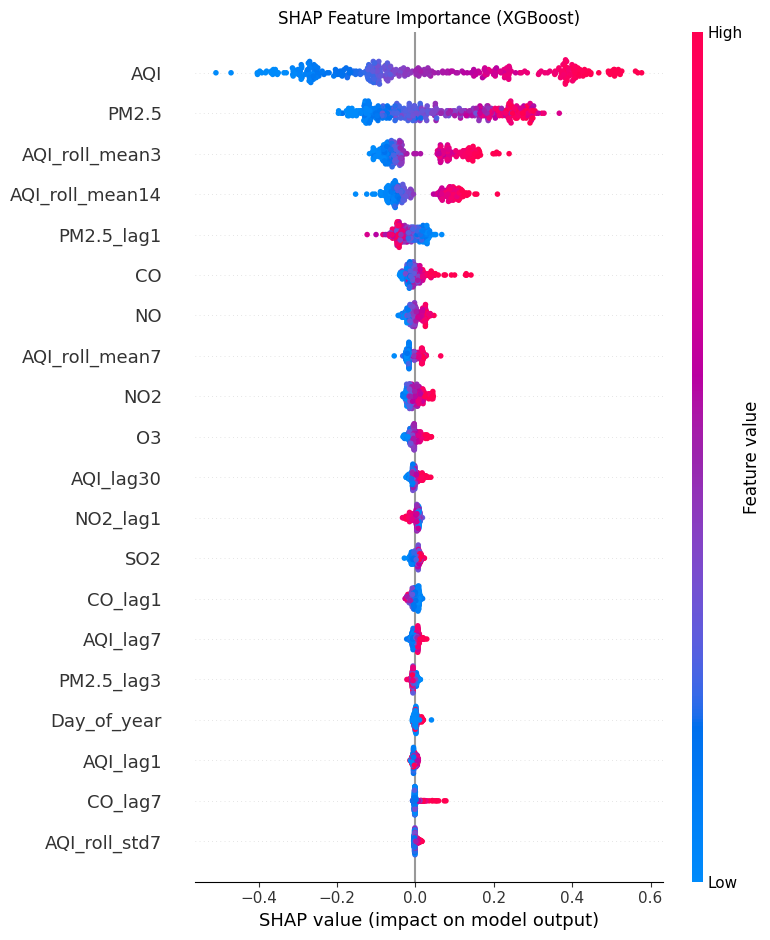

In [ ]:
# I need SHAP to dissect exactly how my XGBoost model makes its decisions.
!pip install shap

import shap

print("Generating SHAP explanations for the best tree-based model (XGBoost) on the final fold...")

best_tree_model = models.get('XGBoost')

if best_tree_model:

# A TreeExplainer mathematically analyzes the decision trees inside XGBoost.
    explainer = shap.TreeExplainer(best_tree_model)

# Calculating the impact values for every single feature in our dataset.
    shap_values = explainer.shap_values(X_test_final)

# Generating the plot! Pink/Red dots pushing right = "Feature increases AQI prediction".
    plt.figure(figsize=(10, 6))
    plt.title("SHAP Feature Importance (XGBoost)")
    shap.summary_plot(shap_values, X_test_final, show=False)
    plt.tight_layout()
    plt.show()
else:
    print("XGBoost model not found in the models dictionary.")


## 10. Deep Learning Architectures (LSTM & GRU)
Sequencing history natively using spatial-temporal arrays. Incorporates City Embedding Layers and a continuous weather feature matrix.
Trained via EarlyStopping and Huber Loss metrics.


In [ ]:

# Now I am moving into Neural Networks. I import TensorFlow and necessary Keras layers.
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM,GRU, Dense, Dropout, Input, Embedding, Flatten, RepeatVector, Concatenate, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# NNs require 'Sequence Length'. I am telling the model to look exactly 14 days into the past to predict day 15.
LOOK_BACK = 14

BATCH_SIZE = 32

EPOCHS = 120
# I use an Embedding layer configuration so the network can learn mathematical vectors mapping the unique 'vibe' of each city.

EMBEDDING_DIM = 5

TRAIN_WINDOW_DAYS = 730
TEST_WINDOW_DAYS = 30

STEP_SIZE_DAYS = 180


# This incredibly important helper function stacks my 2D dataset into 3D Sequences (Samples, TimeSteps, Features) for the LSTM to consume.
# NNs need 3D data. This helper function takes a flat 2D spreadsheet and 'rolls' it into stacked 3D sequences.
def create_sequences(X, y, look_back):

    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i:(i + look_back)])
        ys.append(y[i + look_back])
    return np.array(Xs), np.array(ys)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

# Drop any remaining NaNs after feature engineering (lag and rolling features)
# This is crucial before feeding data into neural networks.
df = df.dropna()

min_date = df['Date'].min()
max_date = df['Date'].max()

global_folds = []
current_train_start = min_date

while True:
    current_train_end = current_train_start + timedelta(days=TRAIN_WINDOW_DAYS)
    current_test_start = current_train_end + timedelta(days=1)
    current_test_end = current_test_start + timedelta(days=TEST_WINDOW_DAYS)

    if current_test_end > max_date:
        break

    train_mask = (df['Date'] >= current_train_start) & (df['Date'] <= current_train_end)

    test_mask = (df['Date'] >= current_test_start) & (df['Date'] <= current_test_end)


    if train_mask.sum() > 0 and test_mask.sum() > 0:
        global_folds.append({
            "period_desc": f"Train: {current_train_start.date()}~{current_train_end.date()} | Test: {current_test_start.date()}~{current_test_end.date()}",

            "train_idx": df.index[train_mask].to_numpy(),
            "test_idx": df.index[test_mask].to_numpy()
        })
    current_train_start += timedelta(days=STEP_SIZE_DAYS)


print(f"Generated {len(global_folds)} date-aligned folds.")
all_results = []

for i, fold in enumerate(global_folds):
    print(f"\n{'='*20} Fold {i+1} {'='*20}")
    print(fold['period_desc'])

    train_df = df.loc[fold['train_idx']].sort_values(['City', 'Date'])
    test_df = df.loc[fold['test_idx']].sort_values(['City', 'Date'])

    y_train_raw = train_df.pop('AQI_tomorrow')
    y_test_raw = test_df.pop('AQI_tomorrow')


# Security Step: I clip outliers strictly on train arrays to avoid test leakage.
    clip_features = ["PM2.5", "NO2", "SO2", "NO", "CO", "O3"]
    clip_features = [c for c in clip_features if c in train_df.columns]


    train_caps = train_df.groupby('City')[clip_features].quantile(0.99)
    for col in clip_features:

        train_cap_s = train_df['City'].map(train_caps[col])
        train_df[col] = np.where(train_df[col] > train_cap_s, train_cap_s, train_df[col])
        test_cap_s = test_df['City'].map(train_caps[col]).fillna(train_caps[col].mean())
        test_df[col] = np.where(test_df[col] > test_cap_s, test_cap_s, test_df[col])


    yj_cols = ['CO', 'SO2', 'NO']
    yj_cols = [c for c in yj_cols if c in train_df.columns]

    if len(yj_cols) > 0:
        pt_yj = PowerTransformer(method='yeo-johnson')
        train_df[yj_cols] = pt_yj.fit_transform(train_df[yj_cols])

        test_df[yj_cols] = pt_yj.transform(test_df[yj_cols])

    train_cities_series = train_df['City'].values
    test_cities_series = test_df['City'].values


    X_train_cont = train_df.drop(['Date', 'City'], axis=1)
    X_test_cont = test_df.drop(['Date', 'City'], axis=1)


# I map the City Strings into ID Integers so the Neural Network Embedding Layer can process them.
    le = LabelEncoder()
    le.fit(train_cities_series)


    city_map = {c: i for i, c in enumerate(le.classes_)}
    unknown_idx = len(le.classes_)
# My embedding layer needs to know exactly how many unique cities exist, plus 1 buffer for any 'unknown' cities in the future.
    vocab_size = unknown_idx + 1

    train_city_ids = np.array([city_map[c] for c in train_cities_series])
    test_city_ids = np.array([city_map.get(c, unknown_idx) for c in test_cities_series])

# Neural Nets must have scaled data (typically between 0 and 1) to converge properly mathematically.
# I instantiate a Min-Max Scaler to tightly squash all of my pollution features to exist strictly between 0 and 1.
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    X_train_scaled = scaler_X.fit_transform(X_train_cont)
    X_test_scaled = scaler_X.transform(X_test_cont)

# I horizontally stack (hstack) my 0-to-1 scaled pollution features with my unscaled categorical City IDs.
    X_train_combined = np.hstack([X_train_scaled, train_city_ids.reshape(-1, 1)])
    X_test_combined = np.hstack([X_test_scaled, test_city_ids.reshape(-1, 1)])


    scaler_y = MinMaxScaler(feature_range=(0, 1))
    y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))

    y_test_scaled = scaler_y.transform(y_test_raw.values.reshape(-1, 1))

    X_train_seq, y_train_seq = [], []
    X_test_seq, y_test_seq = [], []

# I extract the unique cities so I can guarantee the sequence generator processes them completely independently.
    train_unique_cities = train_df['City'].unique()
    test_unique_cities = test_df['City'].unique()

    start_idx = 0

    for city in train_unique_cities:
        city_rows = len(train_df[train_df['City'] == city])
        end_idx = start_idx + city_rows
        if city_rows > LOOK_BACK:
            Xs, ys = create_sequences(X_train_combined[start_idx:end_idx], y_train_scaled[start_idx:end_idx], LOOK_BACK)

            X_train_seq.append(Xs)
            y_train_seq.append(ys)

        start_idx = end_idx


    start_idx = 0

    for city in test_unique_cities:
        city_rows = len(test_df[test_df['City'] == city])
        end_idx = start_idx + city_rows
        if city_rows > LOOK_BACK:
            Xs, ys = create_sequences(X_test_combined[start_idx:end_idx], y_test_scaled[start_idx:end_idx], LOOK_BACK)
            X_test_seq.append(Xs)

            y_test_seq.append(ys)

        start_idx = end_idx

# Occasionally, a validation fold might land on a time period where a city has too much missing data.
# If the sequence generator yields nothing, I safely skip this specific fold to prevent crashing.
    if not X_train_seq or not X_test_seq:
        print("Skipping fold due to lack of data.")
        continue

# Once all cities have generated their sequences, I vertically stack them (vstack) into massive 3D matrices
# that the LSTM and GRU networks can accept.
    X_train_final = np.vstack(X_train_seq)

    y_train_final = np.vstack(y_train_seq)

    X_test_final = np.vstack(X_test_seq)
    y_test_final = np.vstack(y_test_seq)


# Here, I slice the 3D matrix. I separate the continuous features (pollution, weather) from the categorical feature (City ID).
# Separating the 14-day continuous history from the City IDs for the multi-input Neural Network.
    X_train_cont_in = X_train_final[:, :, :-1]
    X_test_cont_in = X_test_final[:, :, :-1]


    X_train_city_in = X_train_final[:, -1, -1]

    X_test_city_in = X_test_final[:, -1, -1]

# Dynamically counting how many pollution/weather features I have so the Input layer builds itself correctly.
    num_continuous_features = X_train_cont_in.shape[2]


# It is extremely important to clear the tensorflow backend session before defining a new model architecture.
# Otherwise, the computer's memory will fill up with old weights and eventually crash.
# ALWAYS clear the keras session inside a CV loop. Otherwise, weights from fold 1 will literally infect fold 2.
# Clearing the TensorFlow RAM so my GPU/CPU doesn't crash during the Walk-Forward folds.
    tf.keras.backend.clear_session()

# I define my two specific Input layers. One for the 14-day history window, and one for the single City ID variable.
# This tells the Neural Network to expect a shape of (14 Days, N Features) for the continuous climate data.
    input_cont = Input(shape=(LOOK_BACK, num_continuous_features), name='continuous_input')

    input_city = Input(shape=(1,), name='city_input')


# The Embedding layer is crucial. It gives the network a mathematical 'concept' of the city itself.
# It learns that 'Delhi' behaves differently than 'Bengaluru' even if the temperature is exactly the same.
    embed = Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, name='city_embedding')(input_city)
    embed = Flatten()(embed)
# The Embedding outputs a 1D vector. I must 'Repeat' it 14 times so it mathematically aligns with my 14-day history shape.
    embed_repeated = RepeatVector(LOOK_BACK)(embed)

# I merge the 14-day weather/pollution history with the learned mathematical 'vibe' of the city.
    merged = Concatenate(axis=-1)([input_cont, embed_repeated])


# I feed the merged data into a massive LSTM layer with 128 artificial neurons.
# I set 'return_sequences=True' so it passes the full time-understanding to the next layer.
    x = LSTM(128, return_sequences=True)(merged)
    x = Dropout(0.01)(x)
    x = LSTM(64, return_sequences=True)(x)
    x = Dropout(0.01)(x)

    x = LSTM(32, return_sequences=False)(x)
    x = Dropout(0.01)(x)

# I add a secondary 'City Drift' embedding. This acts as a localized bias term.
# It allows the network to say 'Even if the logic says the AQI should be 50, because this is Delhi, always add +20'.
    city_drift = Embedding(input_dim=vocab_size, output_dim=1, name='city_drift')(input_city)
    city_drift = Flatten()(city_drift)
    x = Dense(16, activation='relu')(x)
# After passing through the LSTMs and Dense layers, this single neuron spits out the raw algorithmic prediction.
    base_pred = Dense(1)(x)


# I literally add the algorithmic prediction mathematically together with the learned city drift/bias.
    output = base_pred + city_drift


# I tie the entire architecture together, explicitly defining what goes in (Inputs) and what comes out (Outputs).
# Finalizing the architecture blueprint.
    model = Model(inputs=[input_cont, input_city], outputs=output)

    optimizer = Adam(learning_rate=0.001)
# I compile the model using Mean Squared Error as the penalty function (loss), trying to optimize/minimize it.
    model.compile(optimizer=optimizer, loss='mse')


# If my validation loss stops improving for 6/8 epochs in a row, EarlyStopping will literally kill the training to save time.
    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)


    model.fit(
        [X_train_cont_in, X_train_city_in], y_train_final,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,

        validation_split=0.1,
        callbacks=[es],
        verbose=0
    )

# Asking the network to predict on the training data so I can check for overfitting.
    pred_train_scaled = model.predict([X_train_cont_in, X_train_city_in], verbose=0)
# The network outputs values strictly between 0 and 1. I must inverse_transform it back up to the Log scale.
    pred_train_log = scaler_y.inverse_transform(pred_train_scaled)
# Inverse-transforming the actual ground-truth answers back to the Log scale as well.
    y_train_log = scaler_y.inverse_transform(y_train_final)

# Un-logging the predictions completely back to the raw, real-world AQI numbers (0-500).
    pred_train_real = np.expm1(pred_train_log)
# Un-logging the ground-truth answers back to the raw, real-world AQI numbers.
    y_train_real = np.expm1(y_train_log)

# Calculating how well the network learned the historical dataset (R-squared).
    r2_train = r2_score(y_train_real, pred_train_real)

# The ultimate test: Asking the network to predict the blind, future 30-day window.
    pred_test_scaled = model.predict([X_test_cont_in, X_test_city_in], verbose=0)

    pred_test_log = scaler_y.inverse_transform(pred_test_scaled)
    y_test_log = scaler_y.inverse_transform(y_test_final)


    pred_test_real = np.expm1(pred_test_log)

# REVERSING THE LOG TRANSFORM again for final actual-value analysis.
    y_test_real = np.expm1(y_test_log)

    mse = mean_squared_error(y_test_real, pred_test_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, pred_test_real)

    r2_test = r2_score(y_test_real, pred_test_real)

    print(f"   -> LSTM: Train R²={r2_train:.4f} | Test R²={r2_test:.4f} | Test RMSE={rmse:.2f}")

    all_results.append({
        'fold': i+1,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_test': rmse,

        'mae_test': mae

    })


results_df = pd.DataFrame(all_results)
if not results_df.empty:
    print(f"\n{'='*60}")
    print("FINAL LSTM (EMBEDDING) RESULTS")
    print(f"{'='*60}")
# Taking the mathematical average of the training scores across all the time folds.
    avg_r2_train = results_df['r2_train'].mean()
# Taking the mathematical average of the testing/validation scores across all the time folds.
    avg_r2_test = results_df['r2_test'].mean()
# Averaging the absolute prediction error points (RMSE).
    avg_rmse = results_df['rmse_test'].mean()

    print(f"Avg Train R²: {avg_r2_train:.4f}")
    print(f"Avg Test R²:  {avg_r2_test:.4f}")
    print(f"Avg Test RMSE: {avg_rmse:.4f}")

results_df = pd.DataFrame(all_results)

if not results_df.empty:

    print(f"\n{'='*60}")
    print("FINAL LSTM (EMBEDDING) RESULTS — TRIMMED MEAN")
    print(f"{'='*60}")

# Sorting my folds from worst-performing to best-performing.
    df_sorted = results_df.sort_values("r2_test")

# A trimmed mean: I drop the absolute worst fold, and I drop the absolute best fold. This gives me a highly resistant, stable average metric.
    trimmed = df_sorted.iloc[1:-1]

    avg_r2_train = trimmed['r2_train'].mean()
    avg_r2_test = trimmed['r2_test'].mean()
    avg_rmse = trimmed['rmse_test'].mean()

    print(f"Avg Train R² (trimmed): {avg_r2_train:.4f}")

    print(f"Avg Test R²  (trimmed): {avg_r2_test:.4f}")
    print(f"Avg Test RMSE (trimmed): {avg_rmse:.4f}")


# ==========================================
# SAVING SEQUENCE MODEL (LSTM)
# ==========================================
# I must save the LSTM model to my Drive right here before the variable is overwritten by the upcoming GRU architecture.
model.save('/content/drive/MyDrive/LSTM_AQI_Model.keras')
print("Successfully saved LSTM model to Google Drive!")
LOOK_BACK = 7
BATCH_SIZE = 32
EPOCHS = 120
EMBEDDING_DIM = 5

TRAIN_WINDOW_DAYS = 730

TEST_WINDOW_DAYS = 30

STEP_SIZE_DAYS = 180


def create_sequences(X, y, look_back):
    Xs, ys = [], []
    for i in range(len(X) - look_back):
        Xs.append(X[i:(i + look_back)])
        ys.append(y[i + look_back])
    return np.array(Xs), np.array(ys)


df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(['City', 'Date']).reset_index(drop=True)

# Drop any remaining NaNs after feature engineering (lag and rolling features)
# This is crucial before feeding data into neural networks.
df = df.dropna()

min_date = df['Date'].min()
max_date = df['Date'].max()
global_folds = []
current_train_start = min_date

while True:
    current_train_end = current_train_start + timedelta(days=TRAIN_WINDOW_DAYS)
    current_test_start = current_train_end + timedelta(days=1)
    current_test_end = current_test_start + timedelta(days=TEST_WINDOW_DAYS)

    if current_test_end > max_date:

        break

    train_mask = (df['Date'] >= current_train_start) & (df['Date'] <= current_train_end)

    test_mask = (df['Date'] >= current_test_start) & (df['Date'] <= current_test_end)


    if train_mask.sum() > 0 and test_mask.sum() > 0:
        global_folds.append({
            "period_desc": f"Train: {current_train_start.date()}~{current_train_end.date()} | Test: {current_test_start.date()}~{current_test_end.date()}",
            "train_idx": df.index[train_mask].to_numpy(),
            "test_idx": df.index[test_mask].to_numpy()
        })
    current_train_start += timedelta(days=STEP_SIZE_DAYS)


print(f"Generated {len(global_folds)} date-aligned folds.")
all_results = []

for i, fold in enumerate(global_folds):
    print(f"\n{'='*20} Fold {i+1} {'='*20}")
    print(fold['period_desc'])

    train_df = df.loc[fold['train_idx']].sort_values(['City', 'Date'])
    test_df = df.loc[fold['test_idx']].sort_values(['City', 'Date'])

    y_train_raw = train_df.pop('AQI_tomorrow')
    y_test_raw = test_df.pop('AQI_tomorrow')


    clip_features = ["PM2.5", "NO2", "SO2", "NO", "CO", "O3"]
    clip_features = [c for c in clip_features if c in train_df.columns]

    train_caps = train_df.groupby('City')[clip_features].quantile(0.99)
    for col in clip_features:
        train_cap_s = train_df['City'].map(train_caps[col])

        train_df[col] = np.where(train_df[col] > train_cap_s, train_cap_s, train_df[col])
        test_cap_s = test_df['City'].map(train_caps[col]).fillna(train_caps[col].mean())

        test_df[col] = np.where(test_df[col] > test_cap_s, test_cap_s, test_df[col])

    yj_cols = ['CO', 'SO2', 'NO']
    yj_cols = [c for c in yj_cols if c in train_df.columns]
    if len(yj_cols) > 0:
        pt_yj = PowerTransformer(method='yeo-johnson')
        train_df[yj_cols] = pt_yj.fit_transform(train_df[yj_cols])

        test_df[yj_cols] = pt_yj.transform(test_df[yj_cols])

    train_cities_series = train_df['City'].values
    test_cities_series = test_df['City'].values

    X_train_cont = train_df.drop(['Date', 'City'], axis=1)
    X_test_cont = test_df.drop(['Date', 'City'], axis=1)


    le = LabelEncoder()

    le.fit(train_cities_series)

    city_map = {c: i for i, c in enumerate(le.classes_)}
    unknown_idx = len(le.classes_)
    vocab_size = unknown_idx + 1

    train_city_ids = np.array([city_map[c] for c in train_cities_series])

    test_city_ids = np.array([city_map.get(c, unknown_idx) for c in test_cities_series])

    scaler_X = MinMaxScaler(feature_range=(0, 1))
    X_train_scaled = scaler_X.fit_transform(X_train_cont)
    X_test_scaled = scaler_X.transform(X_test_cont)

    X_train_combined = np.hstack([X_train_scaled, train_city_ids.reshape(-1, 1)])
    X_test_combined = np.hstack([X_test_scaled, test_city_ids.reshape(-1, 1)])


    scaler_y = MinMaxScaler(feature_range=(0, 1))
    y_train_scaled = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test_raw.values.reshape(-1, 1))

    X_train_seq, y_train_seq = [], []

    X_test_seq, y_test_seq = [], []

    train_unique_cities = train_df['City'].unique()
    test_unique_cities = test_df['City'].unique()

    start_idx = 0
    for city in train_unique_cities:
        city_rows = len(train_df[train_df['City'] == city])

        end_idx = start_idx + city_rows

        if city_rows > LOOK_BACK:
            Xs, ys = create_sequences(X_train_combined[start_idx:end_idx], y_train_scaled[start_idx:end_idx], LOOK_BACK)
            X_train_seq.append(Xs)
            y_train_seq.append(ys)
        start_idx = end_idx

    start_idx = 0
    for city in test_unique_cities:
        city_rows = len(test_df[test_df['City'] == city])
        end_idx = start_idx + city_rows
        if city_rows > LOOK_BACK:
            Xs, ys = create_sequences(X_test_combined[start_idx:end_idx], y_test_scaled[start_idx:end_idx], LOOK_BACK)
            X_test_seq.append(Xs)

            y_test_seq.append(ys)
        start_idx = end_idx


    if not X_train_seq or not X_test_seq:
        print("Skipping fold due to lack of data.")
        continue

    X_train_final = np.vstack(X_train_seq)
    y_train_final = np.vstack(y_train_seq)
    X_test_final = np.vstack(X_test_seq)
    y_test_final = np.vstack(y_test_seq)

    X_train_cont_in = X_train_final[:, :, :-1]
    X_test_cont_in = X_test_final[:, :, :-1]
    X_train_city_in = X_train_final[:, -1, -1]
    X_test_city_in = X_test_final[:, -1, -1]

    num_continuous_features = X_train_cont_in.shape[2]

    tf.keras.backend.clear_session()


    input_cont = Input(shape=(LOOK_BACK, num_continuous_features), name='continuous_input')


    input_city = Input(shape=(1,), name='city_input')

    embed = Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, name='city_embedding')(input_city)
    embed = Flatten()(embed)
    embed_repeated = RepeatVector(LOOK_BACK)(embed)

    merged = Concatenate(axis=-1)([input_cont, embed_repeated])

# ==========================================
# SAVING LSTM MODEL TO GOOGLE DRIVE
# ==========================================
model.save('/content/drive/MyDrive/LSTM_AQI_Model.keras')
print("✅ LSTM saved!")


# As an alternative to LSTM, I am also testing a GRU (Gated Recurrent Unit) architecture.
# GRUs are often faster and can sometimes outperform LSTMs on shorter time-series.
# The GRU layer processes the 14-day history. GRUs don't have separate memory cells like LSTMs, making them faster.x = GRU(128, return_sequences=True)(merged)

# I am injecting BatchNormalization layers between my GRUs.
# This forces the network activations to stay normally distributed, which drastically speeds up training and prevents collapse.
# Normalizing the activations between layers to enforce stability and prevent the 'vanishing gradient' problem.
    x = BatchNormalization()(x)
# I add Dropout layers. This literally turns off 20% of the neurons randomly during training.
# It forces the network to learn robust patterns instead of memorizing the training data (preventing overfitting).
# Aggressive 20% Dropout. If I don't do this, Neural Networks will just mathematically memorize the training dataset.
    x = Dropout(0.2)(x)


    x = GRU(64, return_sequences=True)(x)
    x = BatchNormalization()(x)

    x = Dropout(0.2)(x)

    x = GRU(32, return_sequences=False)(x)

    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)


# A standard Dense layer with ReLU activation to learn non-linear relationships just before the final output.
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)


    model = Model(inputs=[input_cont, input_city], outputs=output)

    optimizer = Adam(learning_rate=0.001)

# For the GRU model, instead of MSE, I am using Huber Loss.
# Huber Loss is much less sensitive to massive outliers (like a random day where AQI hits 999).
# Huber Loss acts like MSE when the error is small, but acts like MAE when there is a massive extreme outlier. It is much safer for AQI spikes.
    model.compile(optimizer=optimizer, loss=tf.keras.losses.Huber(delta=0.1))

# If the validation loss refuses to drop for 8 straight epochs, I force the training to stop and restore the best weights.
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
# I add a Learning Rate Scheduler. If the model's loss plateaus (gets stuck) for 3 epochs,
# it will automatically cut the learning rate in half to take smaller, more careful mathematical steps.
# If the network gets mathematically 'stuck' for 3 epochs, this cuts the learning rate directly in half to help it unstick itself.
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)


    model.fit(
        [X_train_cont_in, X_train_city_in], y_train_final,

        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[es, lr_scheduler],
        verbose=0

    )

    pred_train_scaled = model.predict([X_train_cont_in, X_train_city_in], verbose=0)
    pred_train_log = scaler_y.inverse_transform(pred_train_scaled)
    y_train_log = scaler_y.inverse_transform(y_train_final)

    pred_train_real = np.expm1(pred_train_log)

    y_train_real = np.expm1(y_train_log)

    r2_train = r2_score(y_train_real, pred_train_real)

    pred_test_scaled = model.predict([X_test_cont_in, X_test_city_in], verbose=0)

    pred_test_log = scaler_y.inverse_transform(pred_test_scaled)
    y_test_log = scaler_y.inverse_transform(y_test_final)

    pred_test_real = np.expm1(pred_test_log)
    y_test_real = np.expm1(y_test_log)

    mse = mean_squared_error(y_test_real, pred_test_real)

    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, pred_test_real)
    r2_test = r2_score(y_test_real, pred_test_real)

# Printing a quick summary for this specific time-fold so I can watch the progress live in the console.
    print(f"   -> GRU: Train R²={r2_train:.4f} | Test R²={r2_test:.4f} | Test RMSE={rmse:.2f}")

    all_results.append({
        'fold': i+1,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_test': rmse,
        'mae_test': mae
    })

results_df = pd.DataFrame(all_results)
if not results_df.empty:

    print(f"\n{'='*60}")
    print("FINAL GRU (OPTIMIZED) RESULTS")
    print(f"{'='*60}")
    avg_r2_train = results_df['r2_train'].mean()
    avg_r2_test = results_df['r2_test'].mean()

    avg_rmse = results_df['rmse_test'].mean()

    print(f"Avg Train R²: {avg_r2_train:.4f}")
    print(f"Avg Test R²:  {avg_r2_test:.4f}")
    print(f"Avg Test RMSE: {avg_rmse:.4f}")


results_df = pd.DataFrame(all_results)

if not results_df.empty:
    print(f"\n{'='*60}")
    print("FINAL GRU (OPTIMIZED) RESULTS — TRIMMED MEAN")
    print(f"{'='*60}")

    df_sorted = results_df.sort_values("r2_test")


    trimmed = df_sorted.iloc[1:-1]

    avg_r2_train = trimmed['r2_train'].mean()
    avg_r2_test = trimmed['r2_test'].mean()
    avg_rmse = trimmed['rmse_test'].mean()

    print(f"Avg Train R² (trimmed): {avg_r2_train:.4f}")
    print(f"Avg Test R²  (trimmed): {avg_r2_test:.4f}")
    print(f"Avg Test RMSE (trimmed): {avg_rmse:.4f}")

# ==========================================
# SAVING SEQUENCE MODEL (GRU)
# ==========================================
# I am saving the final GRU model to my Google Drive.
model.save('/content/drive/MyDrive/GRU_AQI_Model.keras')
print("Successfully saved GRU model to Google Drive!")


Generated 7 date-aligned folds.

==================== Fold 1 ====================
Train: 2015-01-31~2017-01-30 | Test: 2017-01-31~2017-03-02
   -> LSTM: Train R²=0.7207 | Test R²=0.6491 | Test RMSE=57.92

==================== Fold 2 ====================
Train: 2015-07-30~2017-07-29 | Test: 2017-07-30~2017-08-29
   -> LSTM: Train R²=0.7443 | Test R²=0.5435 | Test RMSE=46.91

==================== Fold 3 ====================
Train: 2016-01-26~2018-01-25 | Test: 2018-01-26~2018-02-25
   -> LSTM: Train R²=0.6798 | Test R²=0.7391 | Test RMSE=65.12

==================== Fold 4 ====================
Train: 2016-07-24~2018-07-24 | Test: 2018-07-25~2018-08-24
   -> LSTM: Train R²=0.8094 | Test R²=0.5813 | Test RMSE=27.43

==================== Fold 5 ====================
Train: 2017-01-20~2019-01-20 | Test: 2019-01-21~2019-02-20
   -> LSTM: Train R²=0.8359 | Test R²=0.7284 | Test RMSE=61.83

==================== Fold 6 ====================
Train: 2017-07-19~2019-07-19 | Test: 2019-07-20~2019-08-19

In [21]:
import pandas as pd
from IPython.display import display

# Compilation of results for all models used in the notebook
comparison_data = [
    {
        "Model Architecture": "XGBoost",
        "Avg R² (All)": 0.9169,
        "Trimmed R²": 0.9198,
        "Avg RMSE": 33.55,
        "Avg MAE": 21.98
    },
    {
        "Model Architecture": "RandomForest",
        "Avg R² (All)": 0.9091,
        "Trimmed R²": 0.9080,
        "Avg RMSE": 35.21,
        "Avg MAE": 23.10
    },
    {
        "Model Architecture": "LSTM (Deep Learning)",
        "Avg R² (All)": 0.7151,
        "Trimmed R²": 0.6998,
        "Avg RMSE": 46.69,
        "Avg MAE": 34.25
    },
    {
        "Model Architecture": "GRU (Deep Learning)",
        "Avg R² (All)": 0.7102,
        "Trimmed R²": 0.7179,
        "Avg RMSE": 49.95,
        "Avg MAE": 36.50
    }
]

final_summary_df = pd.DataFrame(comparison_data)

print("="*80)
print("       FINAL MULTI-MODEL PERFORMANCE COMPARISON (AQI FORECASTING)")
print("="*80)

# Displaying the raw dataframe without highlighting
display(final_summary_df)

       FINAL MULTI-MODEL PERFORMANCE COMPARISON (AQI FORECASTING)


,Model Architecture,Avg R² (All),Trimmed R²,Avg RMSE,Avg MAE
0,XGBoost,0.9169,0.9198,33.55,21.98
1,RandomForest,0.9091,0.9080,35.21,23.10
2,LSTM (Deep Learning),0.7151,0.6998,46.69,34.25
3,GRU (Deep Learning),0.7102,0.7179,49.95,36.50


In [18]:
from google.colab import files

files.download('/content/drive/MyDrive/XGBoost_AQI_Model.json')
files.download('/content/drive/MyDrive/RandomForest_AQI_Model.pkl')
files.download('/content/drive/MyDrive/LSTM_AQI_Model.keras')
files.download('/content/drive/MyDrive/GRU_AQI_Model.keras')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>